# **Exercício Computacional: PCA e Redução de Dimensionalidade**

## Orientações
- Use `numpy` e `matplotlib`
- Para carregar datasets, você pode usar `sklearn.datasets`
- Complete as partes indicadas
- Interprete os gráficos obtidos
- Responda às perguntas conceituais ao final

Neste exercício, vamos explorar a **Análise de Componentes Principais (PCA)** sob duas perspectivas:
1. **compressão e reconstrução** de imagens de dígitos
2. **visualização em baixa dimensão** de dados tabulares

Usaremos:
- um dataset de dígitos manuscritos (`digits`, com opção de trocar por MNIST)
- um segundo dataset tabular (`wine`)

In [1]:
# Importando bibliotecas

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits, load_wine, fetch_openml

np.random.seed(42)

---

## Parte 1 — Carregamento e inspeção inicial dos dados

Nesta parte, vamos carregar um dataset de imagens de dígitos.
Por padrão, use o dataset `digits` do `sklearn`, que é pequeno e estável.

Se desejar, você pode tentar usar o MNIST com `fetch_openml`.
Caso faça isso, recomenda-se trabalhar com um subconjunto dos dados.

In [2]:
# Escolha do dataset de imagens
# Sugestão: comece com USE_MNIST = False
# Se quiser usar MNIST, troque para True

USE_MNIST = False

if USE_MNIST:
    # Dica: depois de carregar, selecione apenas um subconjunto para acelerar a atividade
    X_img, y_img = None, None
else:
    digits = load_digits()
    X_img = digits.data
    y_img = digits.target

print("Formato de X_img:", X_img.shape)
print("Formato de y_img:", y_img.shape)
print("Classes:", np.unique(y_img))

Formato de X_img: (1797, 64)
Formato de y_img: (1797,)
Classes: [0 1 2 3 4 5 6 7 8 9]


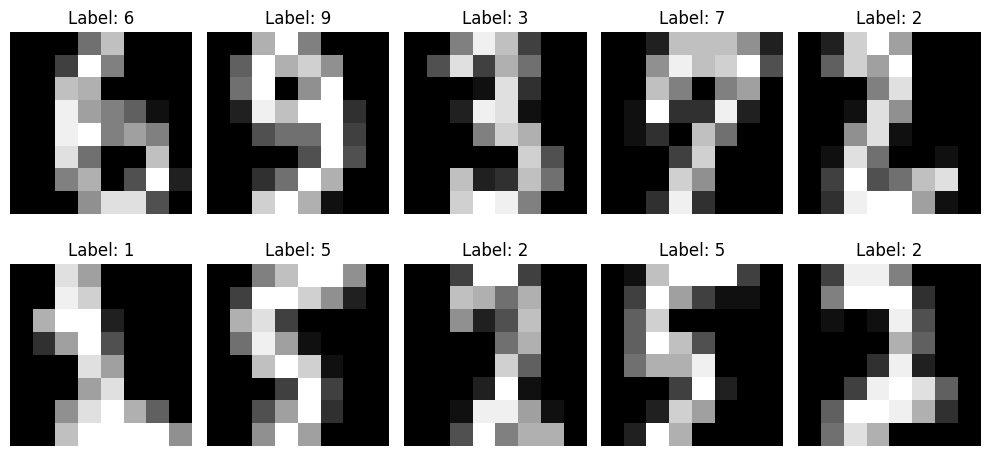

In [4]:
# Visualize algumas imagens do dataset
# Sugestão:
# 1. escolha 10 índices aleatórios
# 2. plote em uma grade 2 x 5
# 3. mostre o rótulo de cada imagem

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
# Insira seu código aqui




plt.tight_layout()
plt.show()

## Parte 2 — Centralização, padronização opcional e matriz de covariância

Considere uma matriz de dados $\mathbf{X} \in \mathbb{R}^{D \times N}$, em que cada coluna é uma amostra.

Implemente as funções auxiliares:
1. centralização dos dados
2. padronização por desvio padrão
3. matriz de covariância amostral

In [6]:
# Centraliza os dados: subtração da média em cada coluna
def center_data(X):
    return

# Padroniza os dados: divide cada coluna pelo desvio padrão
# Dica: trate o caso de desvio padrão zero
def standardize_data(X):
    return

# Calcula a matriz de covariância amostral
# Assuma que X já está centrado
def covariance_matrix(X):
    return

## Parte 3 — Implementando PCA via autodecomposição

Lembre que, para dados centrados, a PCA pode ser obtida a partir dos autovalores e autovetores da matriz de covariância.

Implemente:
1. uma função `pca_fit`
2. uma função `project_data`
3. uma função `reconstruct_data`
4. uma função para variância explicada acumulada

In [ ]:
def pca_fit(X, standardize=False):
    '''
    Entrada:
        X: matriz D x N
        standardize: se True, padroniza além de centralizar

    Saída esperada:
        mean: média das linhas
        scale: desvios-padrão usados na padronização
        eigvals: autovalores em ordem decrescente
        eigvecs: autovetores correspondentes (colunas)
    '''
    return

def project_data(X, mean, scale, eigvecs, M):
    '''
    Retorna as projeções z em dimensão M
    '''
    return

def reconstruct_data(Z, mean, scale, eigvecs, M):
    '''
    Reconstrói os dados no espaço original
    '''
    return

def explained_variance_ratio(eigvals):
    return

## Parte 4 — Ajustando PCA aos dígitos

Nesta parte, ajuste a PCA ao dataset de imagens.

### Tarefas
1. Ajuste a PCA aos dados de imagens
2. Plote os 20 primeiros autovalores
3. Plote a variância explicada acumulada
4. Interprete quantas componentes parecem suficientes para capturar a maior parte da variância

In [ ]:
# Ajuste a PCA nos dados de imagens
# Sugestão: comece sem padronização

mean_img, scale_img, eigvals_img, eigvecs_img = None, None, None, None

# Insira seu código aqui

In [ ]:
# Plote:
# 1. os 20 primeiros autovalores
# 2. a variância explicada acumulada

# Insira seu código aqui

## Parte 5 — Visualização em 2D dos dígitos

Projete os dados no subespaço gerado pelas duas primeiras componentes principais.

### Tarefas
1. Obtenha a projeção 2D
2. Faça um scatter plot
3. Colora os pontos de acordo com o rótulo
4. Comente se algumas classes parecem mais separadas do que outras

In [ ]:
# Projeção em 2D do dataset de imagens

Z2_img = None

# Insira seu código aqui

plt.figure(figsize=(8, 6))
# Insira seu código do scatter aqui
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Dígitos projetados nas duas primeiras componentes principais')
plt.grid(True)
plt.show()

## Parte 6 — Reconstrução de imagens com poucas componentes

Agora vamos usar PCA como técnica de compressão.

### Tarefas
1. Escolha uma imagem do dataset
2. Reconstrua essa imagem usando \(M = 2, 5, 10, 20, 40\) componentes
3. Compare visualmente as reconstruções
4. Comente o efeito do aumento de \(M\)

In [ ]:
# Escolha uma imagem para reconstruir
idx = 0
x0 = X_img[idx:idx+1]

Ms = [2, 5, 10, 20, 40]

# Insira seu código aqui para projetar e reconstruir x0 para diferentes M

# Dica:
# para digits, a imagem é 8x8
# para MNIST, a imagem é 28x28

In [ ]:
# Plote a imagem original e as reconstruções lado a lado

# Insira seu código aqui

## Parte 7 — Erro de reconstrução médio

Vamos quantificar a compressão.

### Tarefas
1. Para \(M = 1, 2, 5, 10, 20, 40\), calcule a reconstrução de todo o dataset
2. Calcule o erro quadrático médio de reconstrução
3. Plote erro de reconstrução em função de \(M\)
4. Interprete o comportamento observado

In [ ]:
def reconstruction_mse(X, X_rec):
    return

Ms = [1, 2, 5, 10, 20, 40]
mse_values = []

# Insira seu código aqui

In [ ]:
# Plote o erro de reconstrução em função de M

# Insira seu código aqui

## Parte 8 — Segundo dataset: Wine

Agora vamos aplicar PCA a um dataset tabular com poucas dimensões,
para visualizar como a PCA pode ajudar na separação de classes.

### Tarefas
1. Carregue o dataset `wine`
2. Aplique PCA com padronização
3. Projete os dados em 2D
4. Faça um scatter plot colorido pelas classes
5. Compare com a visualização nas duas primeiras features originais

In [ ]:
wine = load_wine()
X_wine = wine.data
y_wine = wine.target

print("Formato de X_wine:", X_wine.shape)
print("Classes:", np.unique(y_wine))
print("Nomes das features:", wine.feature_names)

In [ ]:
# Compare:
# 1. scatter usando as duas primeiras features originais
# 2. scatter usando as duas primeiras componentes principais

# Insira seu código aqui

## Parte 9 — Questões conceituais

Responda:

1. Por que é importante centralizar os dados antes de aplicar PCA?
2. Em que situação a padronização é especialmente importante?
3. O que representam os autovalores na PCA?
4. O que significa dizer que PCA realiza uma aproximação de baixo posto?
5. Por que a reconstrução melhora quando aumentamos o número de componentes?
6. A PCA é supervisionada ou não supervisionada?
7. Por que a PCA pode ajudar na visualização, mas nem sempre separar perfeitamente as classes?

Respostas:

1.



2.



3.



4.



5.



6.



7.